# VGG16 Patient-Level Classification with All Metrics and Grad-CAM

This notebook trains and evaluates two independent VGG16 models:

1. **VGG16 `include_top=False`, `base_model.trainable=False`**
2. **VGG16 `include_top=False`, `base_model.trainable=True`**

## Dataset-specific correction

The MRI filenames use this pattern:

```text
PPMI_100890_MR_3D_T1-weighted_..._slice_000.png
```

The patient ID is the number immediately after `PPMI_`.  
For the example above, the patient ID is `100890`.

The folders `control_png` and `pd_png` are intermediate image folders and are
**not patient IDs**.

The notebook verifies that it detects exactly:

- **23 healthy-control patients**
- **29 Parkinson patients**
- **52 total patients**
- **5,560 healthy images**
- **5,560 Parkinson images**
- **11,120 total images**

The split is performed by patient. Every MRI slice from one patient stays
entirely in training, validation, or testing.

With `SEED=42` and a 70%/15%/15% split, the expected patient split is:

| Split | Healthy | Parkinson | Total |
|---|---:|---:|---:|
| Training | 16 | 20 | 36 |
| Validation | 3 | 5 | 8 |
| Testing | 4 | 4 | 8 |
| Total | 23 | 29 | 52 |

## Main outputs

- Best `.keras` model for each VGG16 version
- Accuracy, loss, and AUC graphs
- Patient-level confusion matrices
- Classification reports
- Individual and comparison ROC curves
- Patient prediction CSV files
- Exact split CSV files
- Three ROC `.npz` files

## Explainability

Both the frozen-base and trainable-base VGG16 models generate Grad-CAM
visualizations from representative patient-level testing images. Each
visualization is saved as a PNG and as a raw Grad-CAM `.npz` file.


> **Corrected version:** `control_png` and `pd_png` are no longer treated as patient IDs.

In [1]:

# Check the runtime. In Colab, select:
# Runtime -> Change runtime type -> T4 GPU (or another available GPU)

!nvidia-smi


Wed Jul 29 23:27:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:

# Mount Google Drive

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:

# Imports and reproducibility

import os
import re
import gc
import json
import math
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. Configure the dataset and output paths

The notebook supports these common structures:

### Recommended structure: patient folders

```text
Parkinson_dataset/
├── healthy_dataset/
│   ├── 1001/
│   │   ├── slice_001.png
│   │   └── slice_002.png
│   └── 1002/
└── parkinson_dataset/
    ├── 2001/
    └── 2002/
```

### Flat folders with patient IDs in filenames

```text
healthy_dataset/1001_slice_001.png
healthy_dataset/1001_slice_002.png
parkinson_dataset/2001_slice_001.png
```

For flat folders, edit `PATIENT_ID_REGEX` so that its **first capture group** extracts only the patient ID.


In [4]:
# =========================
# USER CONFIGURATION
# =========================

RUN_UNZIP = True

# Change only this path if your ZIP is stored elsewhere.
ZIP_PATH = (
    "/content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_dataset_here/Parkinson_dataset.zip"
)

EXTRACT_DIR = "/content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_dataset_unzip_here"
DATASET_ROOT = EXTRACT_DIR

OUTPUT_DIR = (
    "/content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here"
)

CLASS_TO_LABEL = {
    "healthy_dataset": 0,
    "parkinson_dataset": 1,
}

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# Exact pattern:
# PPMI_100890_MR_..._slice_000.png -> patient_id = 100890
PATIENT_ID_REGEX = r"(?i)^PPMI_(\d+)_"

EXPECTED_TOTAL_PATIENTS = 52
EXPECTED_HEALTHY_PATIENTS = 23
EXPECTED_PARKINSON_PATIENTS = 29
EXPECTED_TOTAL_IMAGES = 11120
EXPECTED_IMAGES_PER_CLASS = 5560

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

EPOCHS_FROZEN = 30
EPOCHS_TRAINABLE = 30

LEARNING_RATE_FROZEN = 1e-4
LEARNING_RATE_TRAINABLE = 1e-5

USE_HORIZONTAL_FLIP = False
USE_CLASS_WEIGHTS = False
PATIENT_AGGREGATION = "mean"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

GRADCAM_DIR = Path(OUTPUT_DIR) / "gradcam"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

assert abs(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION - 1.0) < 1e-9
print("Output directory:", OUTPUT_DIR)

Output directory: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here


In [5]:

# Extract the ZIP and automatically locate the folder containing both class folders.

def locate_dataset_root(start_path, class_names):
    start_path = Path(start_path)

    if all((start_path / class_name).is_dir() for class_name in class_names):
        return start_path

    candidate_parents = []
    for class_name in class_names:
        candidate_parents.extend(
            p.parent for p in start_path.rglob(class_name) if p.is_dir()
        )

    for parent in candidate_parents:
        if all((parent / class_name).is_dir() for class_name in class_names):
            return parent

    raise FileNotFoundError(
        f"Could not find all class folders {list(class_names)} below {start_path}."
    )


if RUN_UNZIP:
    zip_path = Path(ZIP_PATH)
    if not zip_path.exists():
        raise FileNotFoundError(
            f"ZIP file not found:\n{zip_path}\n\nEdit ZIP_PATH in the configuration cell."
        )

    extract_path = Path(EXTRACT_DIR)
    if extract_path.exists():
        shutil.rmtree(extract_path)
    extract_path.mkdir(parents=True, exist_ok=True)

    shutil.unpack_archive(str(zip_path), str(extract_path))
    print("Dataset extracted to:", extract_path)

DATASET_ROOT = locate_dataset_root(DATASET_ROOT, CLASS_TO_LABEL.keys())
print("Detected dataset root:", DATASET_ROOT)

for class_name in CLASS_TO_LABEL:
    print(class_name, "->", DATASET_ROOT / class_name)


Dataset extracted to: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_dataset_unzip_here
Detected dataset root: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_dataset_unzip_here/Parkinson_dataset
healthy_dataset -> /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_dataset_unzip_here/Parkinson_dataset/healthy_dataset
parkinson_dataset -> /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_dataset_unzip_here/Parkinson_dataset/parkinson_dataset


## 2. Build the image table and extract the correct PPMI patient ID

This code ignores `control_png` and `pd_png`. It extracts each patient ID from
the filename itself:

```text
PPMI_100890_MR_..._slice_000.png
     └────┘
    patient ID
```

In [6]:
# ============================================================
# CORRECT PATIENT-ID EXTRACTION FOR THIS PPMI DATASET
# ============================================================

def patient_id_from_filename(image_path):
    # Example:
    # PPMI_100890_MR_..._slice_000.png -> "100890"
    image_path = Path(image_path)
    match = re.search(PATIENT_ID_REGEX, image_path.name)

    if match is None:
        raise ValueError(
            "Could not extract a PPMI patient ID from filename:\n"
            f"{image_path.name}\n\n"
            "Expected a filename beginning like PPMI_100890_..."
        )

    return str(match.group(1))


records = []
extraction_errors = []

for class_name, label in CLASS_TO_LABEL.items():
    class_dir = Path(DATASET_ROOT) / class_name

    if not class_dir.is_dir():
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    class_images = [
        image_path
        for image_path in class_dir.rglob("*")
        if image_path.is_file()
        and image_path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"{class_name}: found {len(class_images)} images")

    for image_path in sorted(class_images):
        try:
            patient_id = patient_id_from_filename(image_path)
            records.append(
                {
                    "filepath": str(image_path),
                    "filename": image_path.name,
                    "patient_id": patient_id,
                    "label": int(label),
                    "class_name": class_name,
                }
            )
        except Exception as exc:
            extraction_errors.append(
                {"filepath": str(image_path), "error": str(exc)}
            )


if extraction_errors:
    error_df = pd.DataFrame(extraction_errors)
    display(error_df.head(20))
    raise ValueError(
        f"Patient-ID extraction failed for {len(extraction_errors)} images."
    )


images_df = pd.DataFrame(records)

if images_df.empty:
    raise ValueError("No supported MRI images were found.")

images_df["patient_id"] = images_df["patient_id"].astype(str)

print("\nTotal images detected:", len(images_df))
print("Unique patients detected:", images_df["patient_id"].nunique())

print("\nExample extracted patient IDs:")
display(
    images_df[
        ["filename", "patient_id", "class_name", "label"]
    ].head(10)
)

healthy_dataset: found 5560 images
parkinson_dataset: found 5560 images

Total images detected: 11120
Unique patients detected: 52

Example extracted patient IDs:


,filename,patient_id,class_name,label
0,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
1,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
2,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
3,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
4,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
5,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
6,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
7,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
8,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
9,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0


In [7]:
# ============================================================
# STRICT DATASET VALIDATION
# ============================================================

patient_label_counts = images_df.groupby("patient_id")["label"].nunique()
invalid_patients = patient_label_counts[patient_label_counts != 1]

if not invalid_patients.empty:
    display(
        images_df[
            images_df["patient_id"].isin(invalid_patients.index)
        ].sort_values(["patient_id", "label", "filepath"])
    )
    raise ValueError(
        "At least one patient ID appears in both classes."
    )


patient_table = (
    images_df.groupby("patient_id", as_index=False)
    .agg(
        label=("label", "first"),
        class_name=("class_name", "first"),
        number_of_images=("filepath", "size"),
    )
    .sort_values(["label", "patient_id"])
    .reset_index(drop=True)
)


class_summary = (
    patient_table.groupby(["label", "class_name"])
    .agg(
        patients=("patient_id", "nunique"),
        images=("number_of_images", "sum"),
        min_images_per_patient=("number_of_images", "min"),
        median_images_per_patient=("number_of_images", "median"),
        max_images_per_patient=("number_of_images", "max"),
    )
    .reset_index()
)

print("Patients by class:")
display(class_summary)

healthy_patient_count = int(
    patient_table.loc[
        patient_table["label"] == 0, "patient_id"
    ].nunique()
)
parkinson_patient_count = int(
    patient_table.loc[
        patient_table["label"] == 1, "patient_id"
    ].nunique()
)
total_patient_count = int(patient_table["patient_id"].nunique())

healthy_image_count = int((images_df["label"] == 0).sum())
parkinson_image_count = int((images_df["label"] == 1).sum())
total_image_count = int(len(images_df))


assert total_patient_count == EXPECTED_TOTAL_PATIENTS, (
    f"Expected {EXPECTED_TOTAL_PATIENTS} patients but detected "
    f"{total_patient_count}. Do not train."
)
assert healthy_patient_count == EXPECTED_HEALTHY_PATIENTS, (
    f"Expected {EXPECTED_HEALTHY_PATIENTS} healthy patients but detected "
    f"{healthy_patient_count}."
)
assert parkinson_patient_count == EXPECTED_PARKINSON_PATIENTS, (
    f"Expected {EXPECTED_PARKINSON_PATIENTS} Parkinson patients but detected "
    f"{parkinson_patient_count}."
)
assert total_image_count == EXPECTED_TOTAL_IMAGES, (
    f"Expected {EXPECTED_TOTAL_IMAGES} images but detected "
    f"{total_image_count}."
)
assert healthy_image_count == EXPECTED_IMAGES_PER_CLASS, (
    f"Expected {EXPECTED_IMAGES_PER_CLASS} healthy images but detected "
    f"{healthy_image_count}."
)
assert parkinson_image_count == EXPECTED_IMAGES_PER_CLASS, (
    f"Expected {EXPECTED_IMAGES_PER_CLASS} Parkinson images but detected "
    f"{parkinson_image_count}."
)


print("\nDATASET CHECK PASSED")
print(f"Healthy patients: {healthy_patient_count}")
print(f"Parkinson patients: {parkinson_patient_count}")
print(f"Total patients: {total_patient_count}")
print(f"Healthy images: {healthy_image_count}")
print(f"Parkinson images: {parkinson_image_count}")
print(f"Total images: {total_image_count}")

display(patient_table.head(15))

Patients by class:


,label,class_name,patients,images,min_images_per_patient,median_images_per_patient,max_images_per_patient
0,0,healthy_dataset,23,5560,188,192.0,384
1,1,parkinson_dataset,29,5560,188,192.0,192



DATASET CHECK PASSED
Healthy patients: 23
Parkinson patients: 29
Total patients: 52
Healthy images: 5560
Parkinson images: 5560
Total images: 11120


,patient_id,label,class_name,number_of_images
0,100890,0,healthy_dataset,192
1,101747,0,healthy_dataset,192
2,106126,0,healthy_dataset,192
3,106127,0,healthy_dataset,192
4,110686,0,healthy_dataset,192
5,111099,0,healthy_dataset,192
6,113369,0,healthy_dataset,192
7,113447,0,healthy_dataset,188
8,120545,0,healthy_dataset,192
9,130028,0,healthy_dataset,192


## 3. Patient-level 70/15/15 split

In [8]:
# ============================================================
# PATIENT-LEVEL STRATIFIED 70% / 15% / 15% SPLIT
# ============================================================

train_patients, temp_patients = train_test_split(
    patient_table,
    test_size=(VAL_FRACTION + TEST_FRACTION),
    random_state=SEED,
    stratify=patient_table["label"],
)

relative_test_fraction = TEST_FRACTION / (
    VAL_FRACTION + TEST_FRACTION
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=relative_test_fraction,
    random_state=SEED,
    stratify=temp_patients["label"],
)


train_ids = set(train_patients["patient_id"])
val_ids = set(val_patients["patient_id"])
test_ids = set(test_patients["patient_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
assert train_ids | val_ids | test_ids == set(patient_table["patient_id"])


train_df = (
    images_df[images_df["patient_id"].isin(train_ids)]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

val_df = (
    images_df[images_df["patient_id"].isin(val_ids)]
    .sort_values(["patient_id", "filepath"])
    .reset_index(drop=True)
)

test_df = (
    images_df[images_df["patient_id"].isin(test_ids)]
    .sort_values(["patient_id", "filepath"])
    .reset_index(drop=True)
)


def split_rows_for(split_name, patient_part, image_part):
    rows = []
    for label, class_name in [
        (0, "healthy_dataset"),
        (1, "parkinson_dataset"),
    ]:
        rows.append(
            {
                "split": split_name,
                "class_name": class_name,
                "patients": int((patient_part["label"] == label).sum()),
                "images": int((image_part["label"] == label).sum()),
            }
        )
    return rows


split_rows = []
split_rows += split_rows_for("training", train_patients, train_df)
split_rows += split_rows_for("validation", val_patients, val_df)
split_rows += split_rows_for("testing", test_patients, test_df)

split_summary = pd.DataFrame(split_rows)

print("PATIENT-LEVEL SPLIT SUMMARY")
display(split_summary)

patient_count_pivot = (
    split_summary.pivot(
        index="split",
        columns="class_name",
        values="patients",
    )
    .fillna(0)
    .astype(int)
)

patient_count_pivot["total"] = patient_count_pivot.sum(axis=1)

print("\nPATIENT COUNTS ONLY")
display(patient_count_pivot)


expected_patient_counts = {
    "training": {
        "healthy_dataset": 16,
        "parkinson_dataset": 20,
        "total": 36,
    },
    "validation": {
        "healthy_dataset": 3,
        "parkinson_dataset": 5,
        "total": 8,
    },
    "testing": {
        "healthy_dataset": 4,
        "parkinson_dataset": 4,
        "total": 8,
    },
}

for split_name, expected in expected_patient_counts.items():
    actual_healthy = int(
        patient_count_pivot.loc[split_name, "healthy_dataset"]
    )
    actual_parkinson = int(
        patient_count_pivot.loc[split_name, "parkinson_dataset"]
    )
    actual_total = int(
        patient_count_pivot.loc[split_name, "total"]
    )

    assert actual_healthy == expected["healthy_dataset"]
    assert actual_parkinson == expected["parkinson_dataset"]
    assert actual_total == expected["total"]


print("\nEXACT PATIENT SPLIT CHECK PASSED")
print("Training   : 16 healthy + 20 Parkinson = 36 patients")
print("Validation :  3 healthy +  5 Parkinson =  8 patients")
print("Testing    :  4 healthy +  4 Parkinson =  8 patients")
print("Total      : 23 healthy + 29 Parkinson = 52 patients")
print("\nNo patient appears in more than one split.")


split_dir = Path(OUTPUT_DIR) / "patient_splits"
split_dir.mkdir(parents=True, exist_ok=True)

train_patients.sort_values(
    ["label", "patient_id"]
).to_csv(
    split_dir / "train_patients.csv",
    index=False,
)

val_patients.sort_values(
    ["label", "patient_id"]
).to_csv(
    split_dir / "validation_patients.csv",
    index=False,
)

test_patients.sort_values(
    ["label", "patient_id"]
).to_csv(
    split_dir / "test_patients.csv",
    index=False,
)

train_df.to_csv(split_dir / "train_images.csv", index=False)
val_df.to_csv(split_dir / "validation_images.csv", index=False)
test_df.to_csv(split_dir / "test_images.csv", index=False)
split_summary.to_csv(split_dir / "split_summary.csv", index=False)

print("\nSaved exact split files to:", split_dir)

PATIENT-LEVEL SPLIT SUMMARY


,split,class_name,patients,images
0,training,healthy_dataset,16,3648
1,training,parkinson_dataset,20,3832
2,validation,healthy_dataset,3,764
3,validation,parkinson_dataset,5,960
4,testing,healthy_dataset,4,1148
5,testing,parkinson_dataset,4,768



PATIENT COUNTS ONLY


class_name,healthy_dataset,parkinson_dataset,total
split,,,
testing,4,4,8
training,16,20,36
validation,3,5,8



EXACT PATIENT SPLIT CHECK PASSED
Training   : 16 healthy + 20 Parkinson = 36 patients
Validation :  3 healthy +  5 Parkinson =  8 patients
Testing    :  4 healthy +  4 Parkinson =  8 patients
Total      : 23 healthy + 29 Parkinson = 52 patients

No patient appears in more than one split.

Saved exact split files to: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here/patient_splits


## 4. TensorFlow input pipeline

In [9]:

AUTOTUNE = tf.data.AUTOTUNE

augmentation_layers = [
    layers.RandomRotation(0.04, fill_mode="nearest", seed=SEED),
    layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="nearest",
        seed=SEED,
    ),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="nearest",
        seed=SEED,
    ),
]

if USE_HORIZONTAL_FLIP:
    augmentation_layers.insert(
        0, layers.RandomFlip("horizontal", seed=SEED)
    )

data_augmentation = keras.Sequential(
    augmentation_layers,
    name="medical_image_augmentation",
)


def decode_and_resize(filepath, label):
    image_bytes = tf.io.read_file(filepath)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label


def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label


def only_preprocess(image, label):
    image = preprocess_input(image)
    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].astype(str).to_numpy()
    labels = dataframe["label"].astype(np.float32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    options = tf.data.Options()
    options.experimental_deterministic = not training
    dataset = dataset.with_options(options)

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        decode_and_resize,
        num_parallel_calls=AUTOTUNE,
    )

    if training:
        dataset = dataset.map(
            augment_and_preprocess,
            num_parallel_calls=AUTOTUNE,
        )
    else:
        dataset = dataset.map(
            only_preprocess,
            num_parallel_calls=AUTOTUNE,
        )

    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

sample_images, sample_labels = next(iter(train_ds))
print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Preprocessed image range:", float(tf.reduce_min(sample_images)),
      "to", float(tf.reduce_max(sample_images)))


Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Preprocessed image range: -123.68000030517578 to 127.5092544555664


In [10]:

# Optional image-level class weights, computed using training images only.

class_weight = None

if USE_CLASS_WEIGHTS:
    counts = train_df["label"].value_counts().sort_index()
    total = len(train_df)
    number_of_classes = len(counts)

    class_weight = {
        int(label): float(total / (number_of_classes * count))
        for label, count in counts.items()
    }

print("Class weight:", class_weight)


Class weight: None


## 5. Model, callbacks, plots, and patient-level ROC saving

In [11]:

def build_vgg16_model(base_trainable, learning_rate, model_name):
    inputs = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="preprocessed_mri_image",
    )

    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base_model.trainable = base_trainable

    # VGG16 has no BatchNormalization layers, so training=True is acceptable
    # when the complete backbone is intentionally trainable.
    x = base_model(inputs, training=base_trainable)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.BatchNormalization(name="head_batch_normalization")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.50, name="dropout_1")(x)
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.Dropout(0.30, name="dropout_2")(x)
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="parkinson_probability",
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    return model



def save_model_summary(model, run_dir, run_name):
    summary_lines = []

    model.summary(
        print_fn=lambda line: summary_lines.append(line)
    )

    summary_path = (
        run_dir / f"{run_name}_model_summary.txt"
    )

    summary_path.write_text(
        "\n".join(summary_lines),
        encoding="utf-8",
    )

    print("\n".join(summary_lines))
    print("Saved model summary:", summary_path)



def make_callbacks(run_name):
    run_dir = Path(OUTPUT_DIR) / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    best_weights_path = run_dir / f"{run_name}_best.weights.h5"
    history_log_path = run_dir / f"{run_name}_epoch_log.csv"

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=7,
            restore_best_weights=False,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            filename=str(history_log_path),
            append=False,
        ),
        keras.callbacks.TerminateOnNaN(),
    ]

    return callbacks, best_weights_path, run_dir


def save_history(history, run_dir, run_name):
    history_df = pd.DataFrame(history.history)
    history_csv = run_dir / f"{run_name}_history.csv"
    history_df.to_csv(history_csv, index=False)

    metric_pairs = [
        ("loss", "val_loss"),
        ("accuracy", "val_accuracy"),
        ("auc", "val_auc"),
        ("precision", "val_precision"),
        ("recall", "val_recall"),
    ]

    for train_metric, val_metric in metric_pairs:
        if train_metric not in history_df or val_metric not in history_df:
            continue

        plt.figure(figsize=(8, 5))
        epochs = np.arange(1, len(history_df) + 1)
        plt.plot(epochs, history_df[train_metric], label=f"Train {train_metric}")
        plt.plot(epochs, history_df[val_metric], label=f"Validation {train_metric}")
        plt.xlabel("Epoch")
        plt.ylabel(train_metric.upper())
        plt.title(f"{run_name}: {train_metric}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            run_dir / f"{run_name}_{train_metric}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()
        plt.close()

    return history_df


def aggregate_patient_probabilities(prediction_df, method):
    grouped = prediction_df.groupby("patient_id", as_index=False)

    if method == "mean":
        patient_eval = grouped.agg(
            y_true=("label", "first"),
            y_score=("y_score", "mean"),
            number_of_images=("filepath", "size"),
        )
    elif method == "median":
        patient_eval = grouped.agg(
            y_true=("label", "first"),
            y_score=("y_score", "median"),
            number_of_images=("filepath", "size"),
        )
    elif method == "max":
        patient_eval = grouped.agg(
            y_true=("label", "first"),
            y_score=("y_score", "max"),
            number_of_images=("filepath", "size"),
        )
    else:
        raise ValueError("PATIENT_AGGREGATION must be mean, median, or max.")

    return patient_eval


def evaluate_and_save_patient_roc(
    model,
    dataframe,
    dataset,
    run_dir,
    run_name,
    roc_npz_filename,
    threshold=0.5,
):
    y_true_image = dataframe["label"].astype(int).to_numpy()
    y_score_image = model.predict(dataset, verbose=1).reshape(-1)

    if len(y_score_image) != len(dataframe):
        raise RuntimeError(
            f"Prediction count {len(y_score_image)} does not match "
            f"test image count {len(dataframe)}."
        )

    image_predictions = dataframe[
        ["filepath", "filename", "patient_id", "label", "class_name"]
    ].copy()
    image_predictions["y_score"] = y_score_image
    image_predictions["y_pred"] = (y_score_image >= threshold).astype(int)

    image_predictions.to_csv(
        run_dir / f"{run_name}_image_predictions.csv",
        index=False,
    )

    # Confirm each patient has only one true class.
    if (image_predictions.groupby("patient_id")["label"].nunique() != 1).any():
        raise ValueError("A test patient has images with inconsistent labels.")

    patient_eval = aggregate_patient_probabilities(
        image_predictions,
        PATIENT_AGGREGATION,
    )
    patient_eval["y_pred"] = (
        patient_eval["y_score"] >= threshold
    ).astype(int)
    patient_eval["true_class"] = patient_eval["y_true"].map(
        {0: "healthy_dataset", 1: "parkinson_dataset"}
    )
    patient_eval["predicted_class"] = patient_eval["y_pred"].map(
        {0: "healthy_dataset", 1: "parkinson_dataset"}
    )

    y_true = patient_eval["y_true"].astype(int).to_numpy()
    y_score = patient_eval["y_score"].astype(float).to_numpy()
    y_pred = patient_eval["y_pred"].astype(int).to_numpy()

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )
    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0.0
    )

    if len(np.unique(y_true)) != 2:
        raise ValueError(
            "The patient-level test set must contain both classes to compute ROC."
        )

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    patient_auc = roc_auc_score(y_true, y_score)

    metrics = {
        "model": run_name,
        "split_level": "patient",
        "aggregation": PATIENT_AGGREGATION,
        "decision_threshold": float(threshold),
        "number_of_test_patients": int(len(patient_eval)),
        "number_of_test_images": int(len(image_predictions)),
        "patient_accuracy": float(accuracy_score(y_true, y_pred)),
        "patient_precision": float(
            precision_score(y_true, y_pred, zero_division=0)
        ),
        "patient_recall": float(
            recall_score(y_true, y_pred, zero_division=0)
        ),
        "patient_f1": float(
            f1_score(y_true, y_pred, zero_division=0)
        ),
        "patient_specificity": float(specificity),
        "patient_negative_predictive_value": float(
            negative_predictive_value
        ),
        "patient_balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "patient_matthews_correlation_coefficient": float(
            matthews_corrcoef(y_true, y_pred)
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "patient_roc_auc": float(patient_auc),
    }

    patient_eval.to_csv(
        run_dir / f"{run_name}_patient_predictions.csv",
        index=False,
    )

    with open(
        run_dir / f"{run_name}_patient_metrics.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metrics, file, indent=2)

    pd.DataFrame([metrics]).to_csv(
        run_dir / f"{run_name}_patient_metrics.csv",
        index=False,
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["healthy_dataset", "parkinson_dataset"],
        digits=4,
        zero_division=0,
    )

    with open(
        run_dir / f"{run_name}_patient_classification_report.txt",
        "w",
        encoding="utf-8",
    ) as file:
        file.write(report)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=["Actual healthy", "Actual Parkinson"],
        columns=["Predicted healthy", "Predicted Parkinson"],
    )
    cm_df.to_csv(
        run_dir / f"{run_name}_patient_confusion_matrix.csv"
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"{run_name}\nPatient-level confusion matrix")
    plt.colorbar()
    tick_positions = np.arange(2)
    plt.xticks(tick_positions, ["Healthy", "Parkinson"])
    plt.yticks(tick_positions, ["Healthy", "Parkinson"])
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")

    for row in range(cm.shape[0]):
        for column in range(cm.shape[1]):
            plt.text(
                column,
                row,
                str(cm[row, column]),
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.savefig(
        run_dir / f"{run_name}_patient_confusion_matrix.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{run_name} (AUC = {patient_auc:.4f})",
    )
    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{run_name}\nPatient-level ROC")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    roc_png_path = run_dir / f"{run_name}_patient_level_roc.png"
    plt.savefig(roc_png_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    # Main requested ROC NPZ file.
    roc_npz_path = Path(OUTPUT_DIR) / roc_npz_filename
    np.savez_compressed(
        roc_npz_path,
        patient_ids=patient_eval["patient_id"].astype(str).to_numpy(dtype="U"),
        y_true=y_true.astype(np.int64),
        y_score=y_score.astype(np.float64),
        y_pred=y_pred.astype(np.int64),
        fpr=fpr.astype(np.float64),
        tpr=tpr.astype(np.float64),
        thresholds=roc_thresholds.astype(np.float64),
        auc=np.asarray(patient_auc, dtype=np.float64),
        decision_threshold=np.asarray(threshold, dtype=np.float64),
        aggregation=np.asarray(PATIENT_AGGREGATION),
        split_level=np.asarray("patient"),
        positive_class=np.asarray("parkinson_dataset"),
        negative_class=np.asarray("healthy_dataset"),
        number_of_images=patient_eval["number_of_images"].to_numpy(
            dtype=np.int64
        ),
        model_name=np.asarray(run_name),
    )

    print("\nPatient-level classification report:\n")
    print(report)
    print("Patient-level metrics:")
    print(json.dumps(metrics, indent=2))
    print("\nSaved ROC NPZ:", roc_npz_path)

    return {
        "metrics": metrics,
        "patient_predictions": patient_eval,
        "image_predictions": image_predictions,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": roc_thresholds,
        "auc": patient_auc,
        "roc_npz_path": str(roc_npz_path),
        "roc_png_path": str(roc_png_path),
    }


## 6. Train VGG16 with the convolutional base frozen

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16_base_frozen_patient_level"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessed_mri_image          │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_normalization        │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ parkinson_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,864,577 (56.70 MB)

 Trainable params: 148,865 (581.50 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

Model: "vgg16_base_frozen_patient_level"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessed_mri_image          │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_normalization        │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │

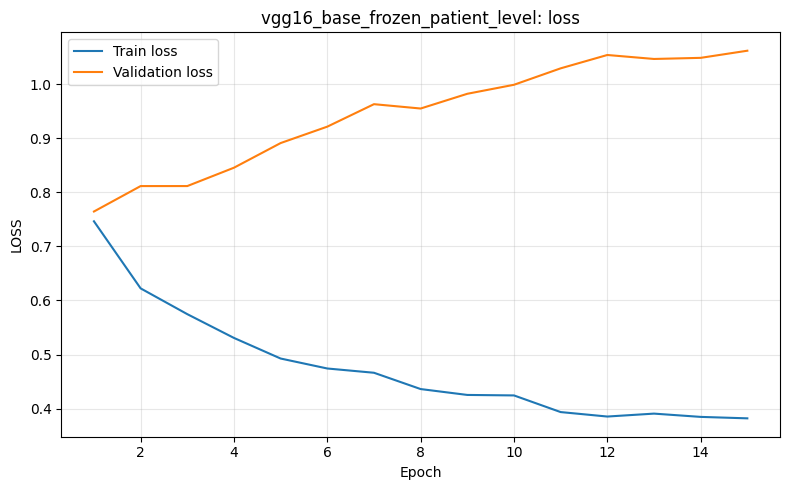

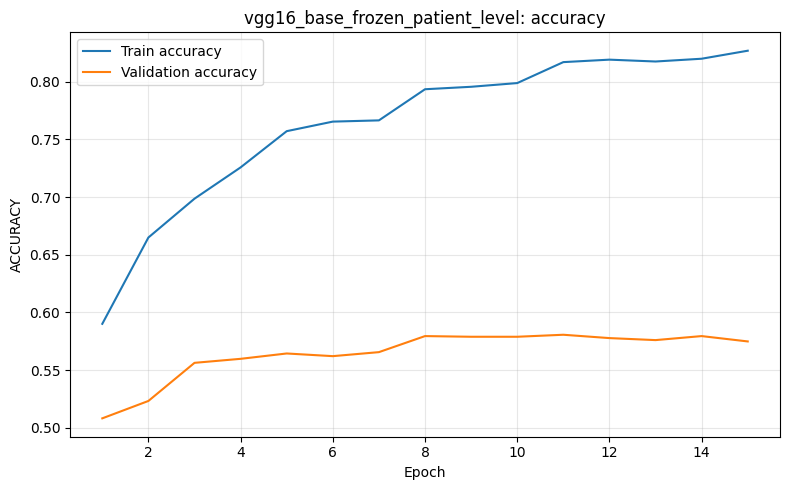

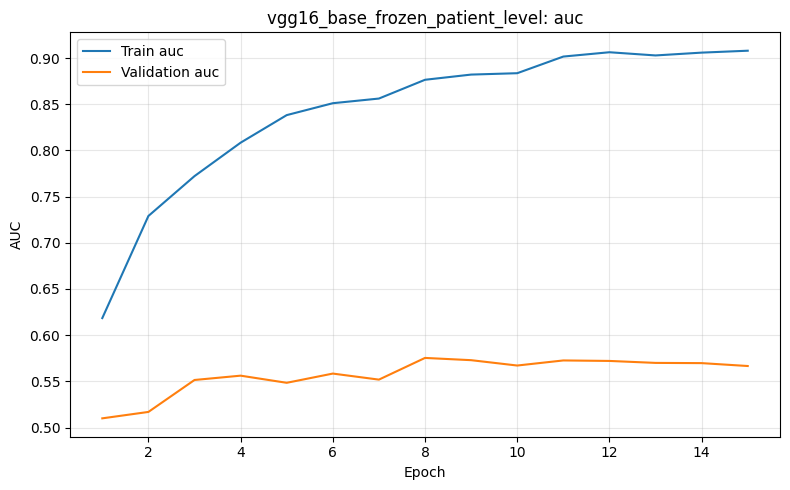

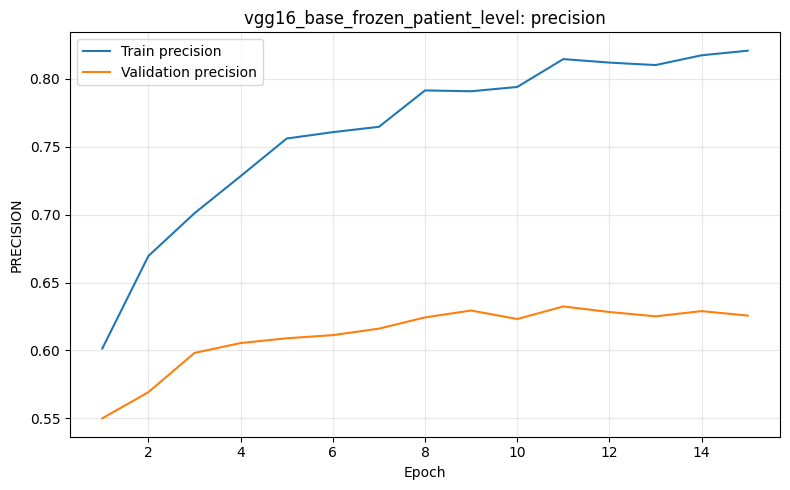

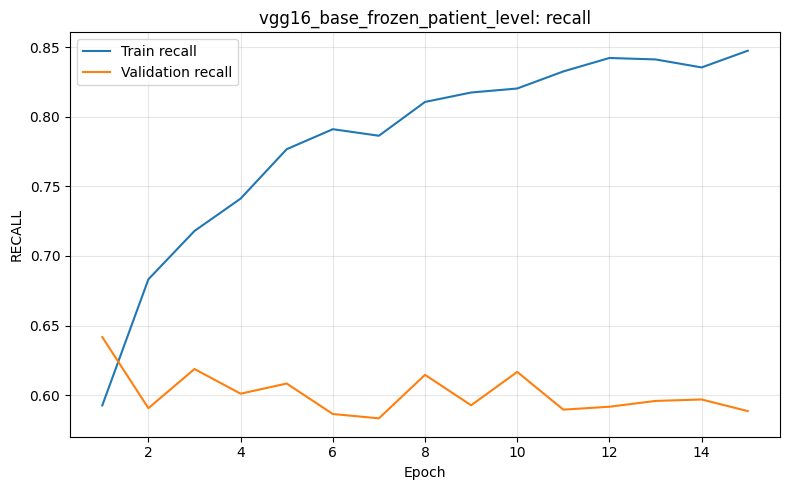

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step


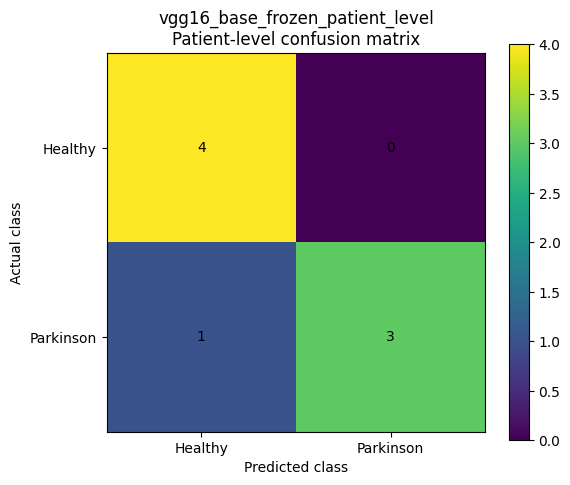

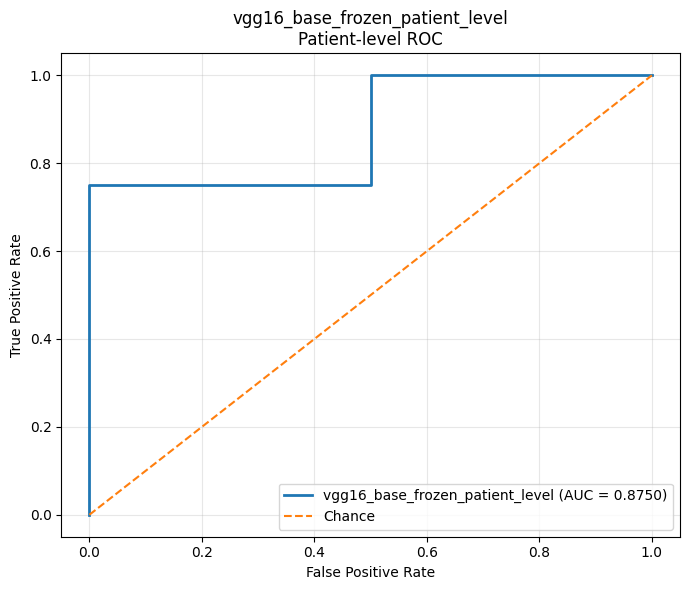


Patient-level classification report:

                   precision    recall  f1-score   support

  healthy_dataset     0.8000    1.0000    0.8889         4
parkinson_dataset     1.0000    0.7500    0.8571         4

         accuracy                         0.8750         8
        macro avg     0.9000    0.8750    0.8730         8
     weighted avg     0.9000    0.8750    0.8730         8

Patient-level metrics:
{
  "model": "vgg16_base_frozen_patient_level",
  "split_level": "patient",
  "aggregation": "mean",
  "decision_threshold": 0.5,
  "number_of_test_patients": 8,
  "number_of_test_images": 1916,
  "patient_accuracy": 0.875,
  "patient_precision": 1.0,
  "patient_recall": 0.75,
  "patient_f1": 0.8571428571428571,
  "patient_specificity": 1.0,
  "patient_negative_predictive_value": 0.8,
  "patient_balanced_accuracy": 0.875,
  "patient_matthews_correlation_coefficient": 0.7745966692414834,
  "true_negative": 4,
  "false_positive": 0,
  "false_negative": 1,
  "true_positive": 3,

In [12]:

FROZEN_RUN_NAME = "vgg16_base_frozen_patient_level"

tf.keras.backend.clear_session()
gc.collect()

frozen_model = build_vgg16_model(
    base_trainable=False,
    learning_rate=LEARNING_RATE_FROZEN,
    model_name=FROZEN_RUN_NAME,
)
frozen_model.summary()

frozen_callbacks, frozen_best_weights, frozen_run_dir = make_callbacks(
    FROZEN_RUN_NAME
)

save_model_summary(
    frozen_model,
    frozen_run_dir,
    FROZEN_RUN_NAME,
)

frozen_start = time.time()

frozen_history = frozen_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=frozen_callbacks,
    class_weight=class_weight,
    verbose=1,
)

frozen_minutes = (time.time() - frozen_start) / 60
print(f"Frozen-base training time: {frozen_minutes:.2f} minutes")

frozen_model.load_weights(frozen_best_weights)
frozen_model.save(
    frozen_run_dir / f"{FROZEN_RUN_NAME}_best_model.keras"
)

frozen_history_df = save_history(
    frozen_history,
    frozen_run_dir,
    FROZEN_RUN_NAME,
)

frozen_results = evaluate_and_save_patient_roc(
    model=frozen_model,
    dataframe=test_df,
    dataset=test_ds,
    run_dir=frozen_run_dir,
    run_name=FROZEN_RUN_NAME,
    roc_npz_filename="vgg16_base_frozen_patient_level_roc.npz",
)


## 7. Train VGG16 with the complete convolutional base trainable

Model: "vgg16_base_trainable_patient_level"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessed_mri_image          │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_normalization        │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ parkinson_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,864,577 (56.70 MB)

 Trainable params: 14,863,553 (56.70 MB)

 Non-trainable params: 1,024 (4.00 KB)

Model: "vgg16_base_trainable_patient_level"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessed_mri_image          │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_normalization        │ (None, 512)            │         2,048 │
│ (BatchNormalization)          

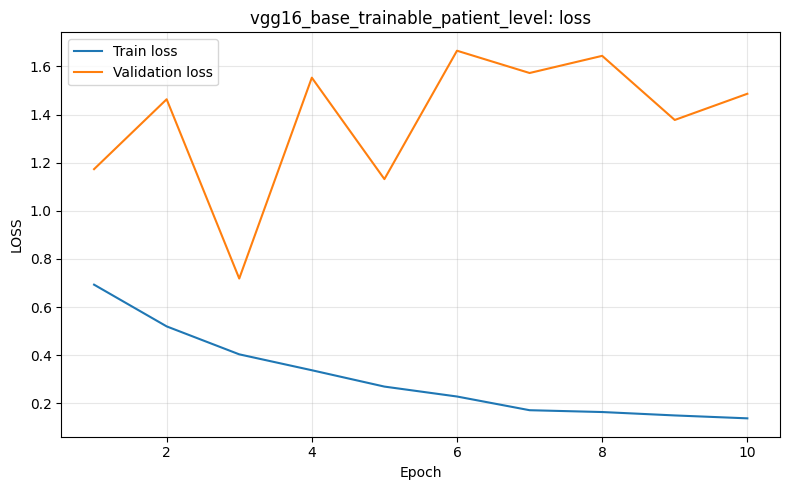

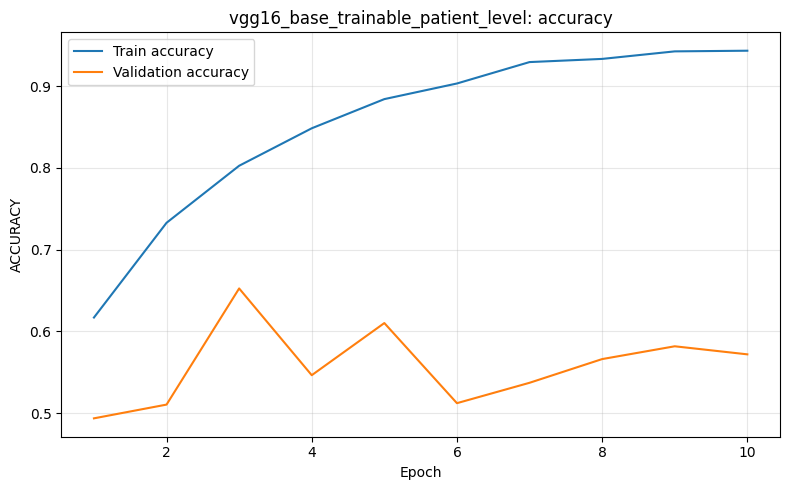

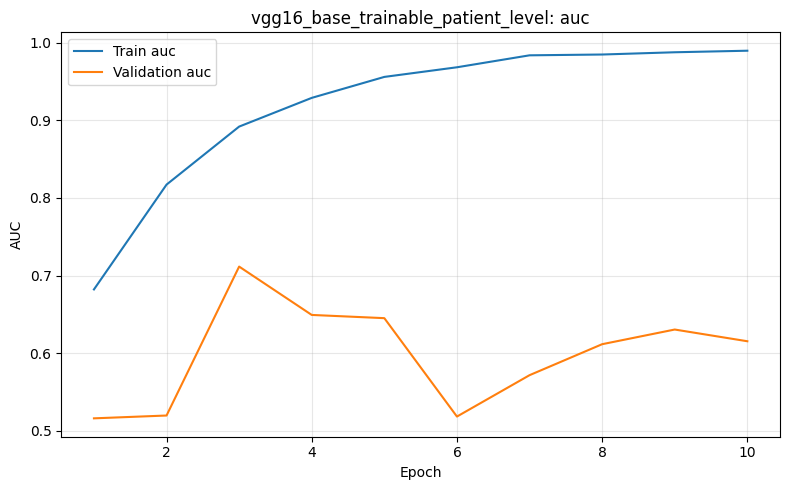

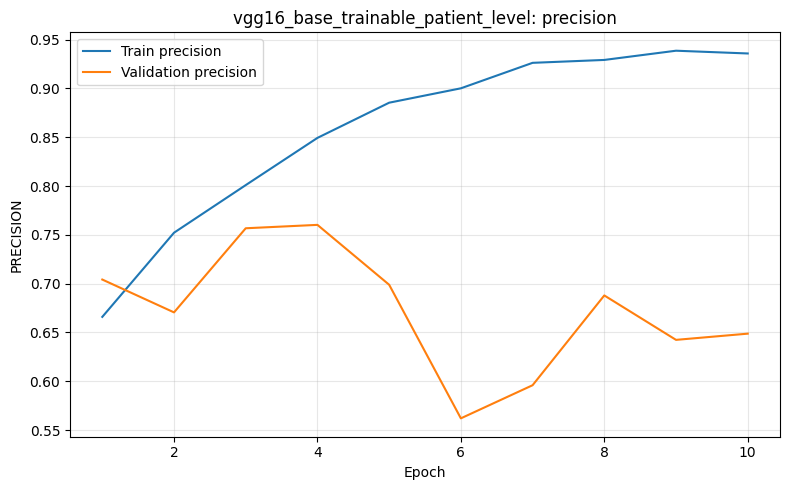

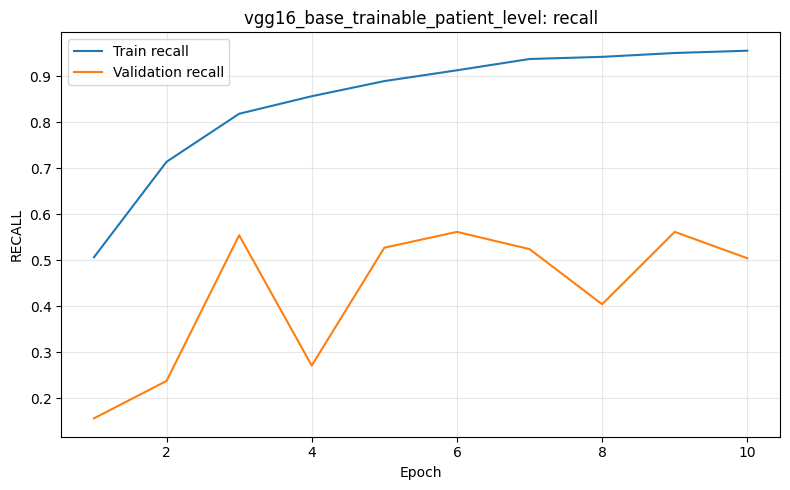

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step


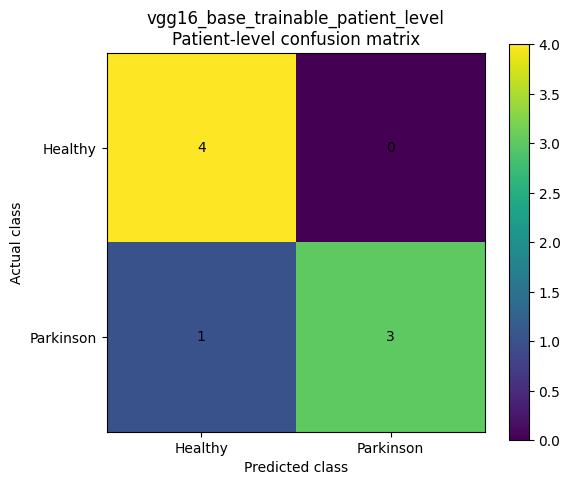

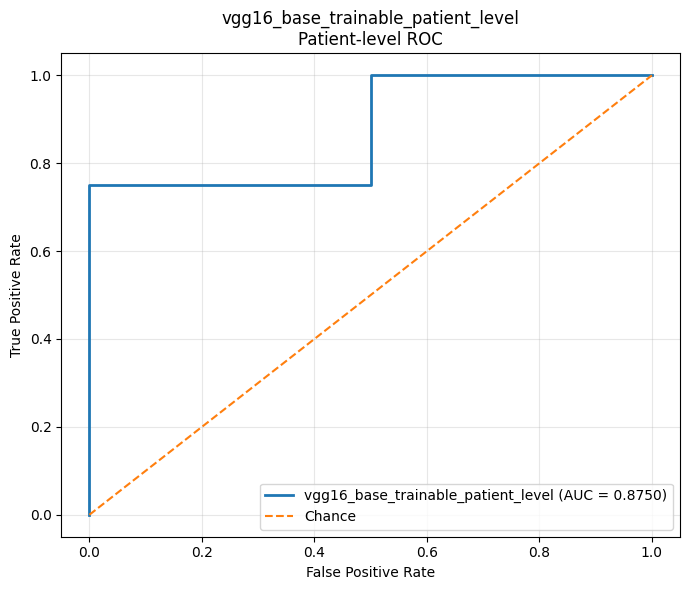


Patient-level classification report:

                   precision    recall  f1-score   support

  healthy_dataset     0.8000    1.0000    0.8889         4
parkinson_dataset     1.0000    0.7500    0.8571         4

         accuracy                         0.8750         8
        macro avg     0.9000    0.8750    0.8730         8
     weighted avg     0.9000    0.8750    0.8730         8

Patient-level metrics:
{
  "model": "vgg16_base_trainable_patient_level",
  "split_level": "patient",
  "aggregation": "mean",
  "decision_threshold": 0.5,
  "number_of_test_patients": 8,
  "number_of_test_images": 1916,
  "patient_accuracy": 0.875,
  "patient_precision": 1.0,
  "patient_recall": 0.75,
  "patient_f1": 0.8571428571428571,
  "patient_specificity": 1.0,
  "patient_negative_predictive_value": 0.8,
  "patient_balanced_accuracy": 0.875,
  "patient_matthews_correlation_coefficient": 0.7745966692414834,
  "true_negative": 4,
  "false_positive": 0,
  "false_negative": 1,
  "true_positive":

In [13]:

# Release the first model before constructing the fully trainable VGG16.
del frozen_model
tf.keras.backend.clear_session()
gc.collect()

TRAINABLE_RUN_NAME = "vgg16_base_trainable_patient_level"

trainable_model = build_vgg16_model(
    base_trainable=True,
    learning_rate=LEARNING_RATE_TRAINABLE,
    model_name=TRAINABLE_RUN_NAME,
)
trainable_model.summary()

trainable_callbacks, trainable_best_weights, trainable_run_dir = make_callbacks(
    TRAINABLE_RUN_NAME
)

save_model_summary(
    trainable_model,
    trainable_run_dir,
    TRAINABLE_RUN_NAME,
)

trainable_start = time.time()

trainable_history = trainable_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRAINABLE,
    callbacks=trainable_callbacks,
    class_weight=class_weight,
    verbose=1,
)

trainable_minutes = (time.time() - trainable_start) / 60
print(f"Trainable-base training time: {trainable_minutes:.2f} minutes")

trainable_model.load_weights(trainable_best_weights)
trainable_model.save(
    trainable_run_dir / f"{TRAINABLE_RUN_NAME}_best_model.keras"
)

trainable_history_df = save_history(
    trainable_history,
    trainable_run_dir,
    TRAINABLE_RUN_NAME,
)

trainable_results = evaluate_and_save_patient_roc(
    model=trainable_model,
    dataframe=test_df,
    dataset=test_ds,
    run_dir=trainable_run_dir,
    run_name=TRAINABLE_RUN_NAME,
    roc_npz_filename="vgg16_base_trainable_patient_level_roc.npz",
)


## Grad-CAM for frozen and trainable VGG16 models

GRAD-CAM TEST SAMPLES


,patient_id,label,class_name,filename
0,113447,0,healthy_dataset,PPMI_113447_MR_SAG_3D_T1-weighted_br_raw_20220...
1,130190,0,healthy_dataset,PPMI_130190_MR_3D_T1_MPRAGE_br_raw_20220225013...
2,101179,1,parkinson_dataset,PPMI_101179_MR_3D_T1-weighted_br_raw_202109162...
3,101295,1,parkinson_dataset,"PPMI_101295_MR_T1-weighted,_3D_VOLUMETRIC_br_r..."



Loading Grad-CAM model: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here/vgg16_base_frozen_patient_level/vgg16_base_frozen_patient_level_best_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['preprocessed_mri_image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


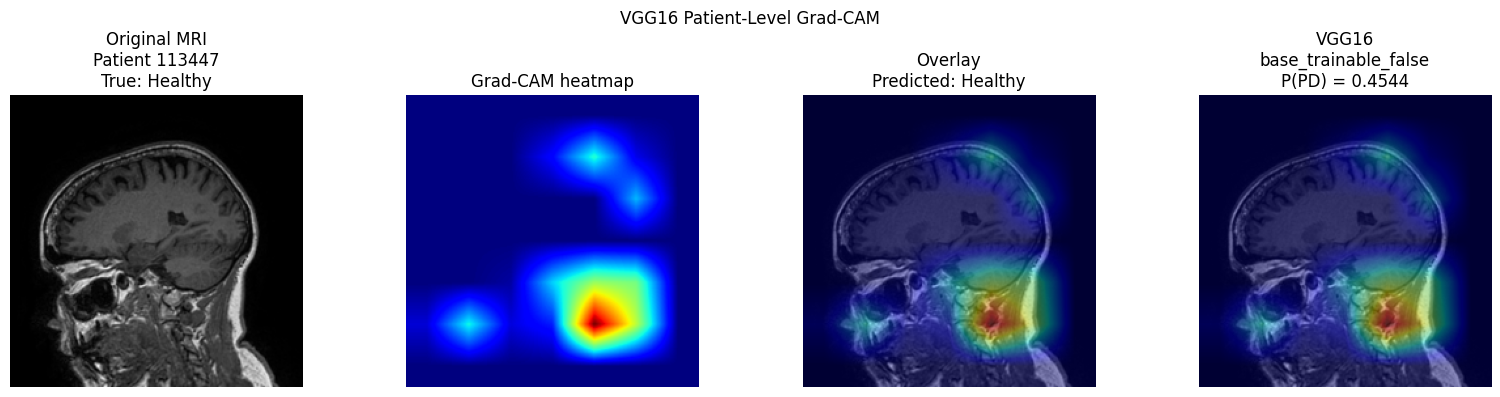

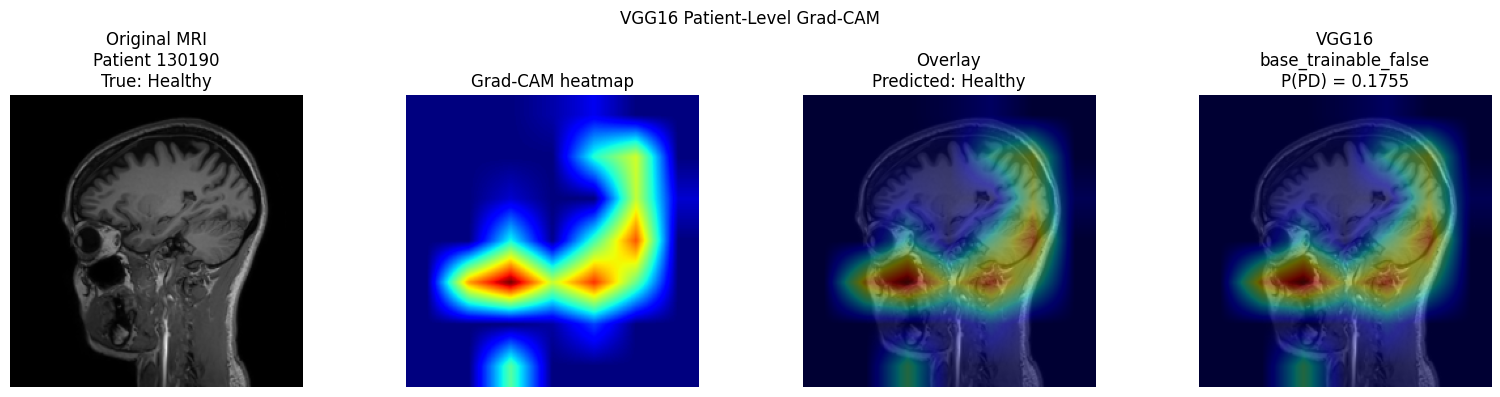

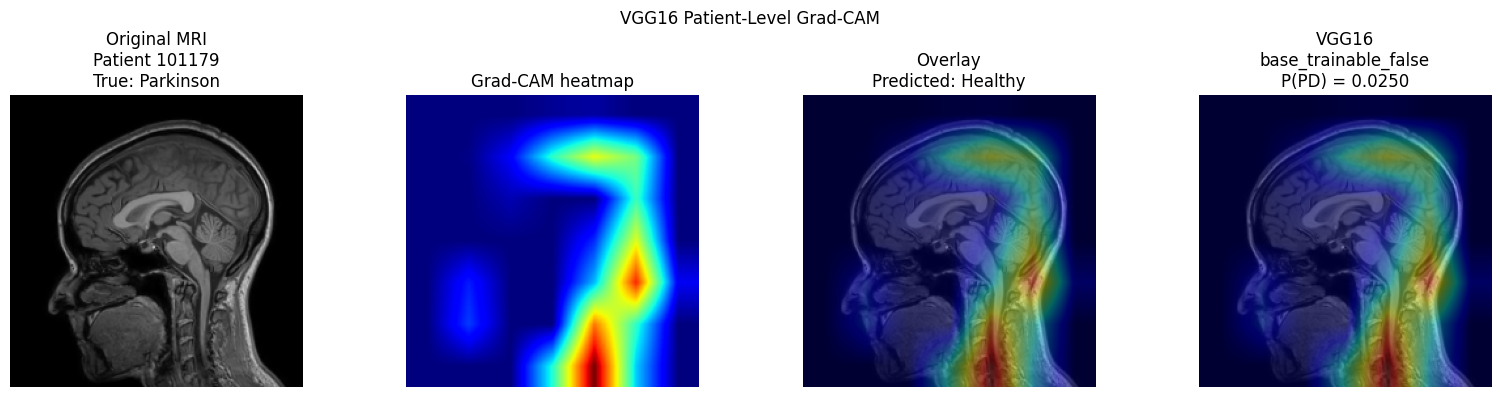

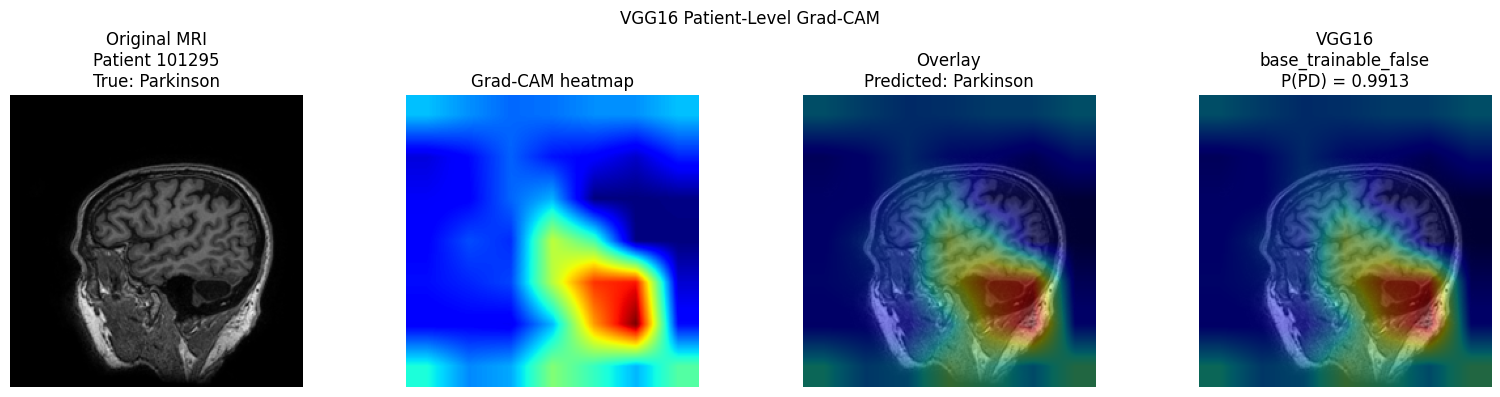


Loading Grad-CAM model: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here/vgg16_base_trainable_patient_level/vgg16_base_trainable_patient_level_best_model.keras


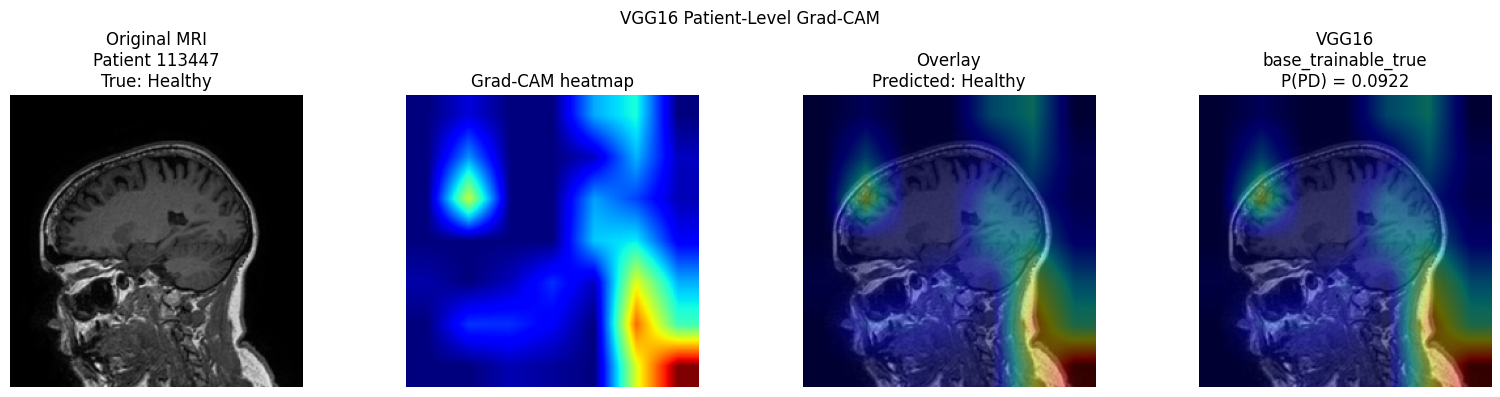

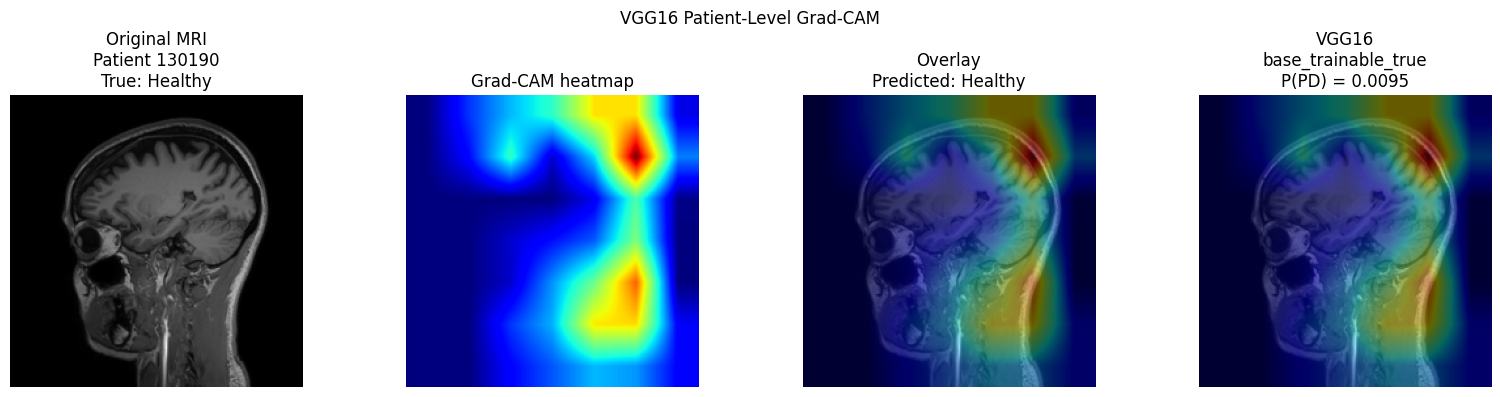

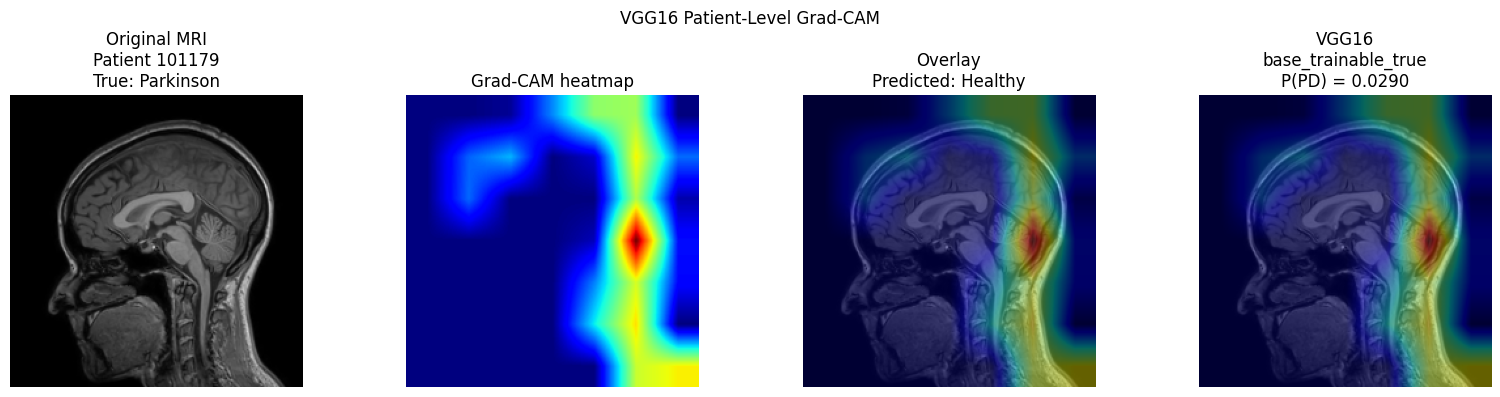

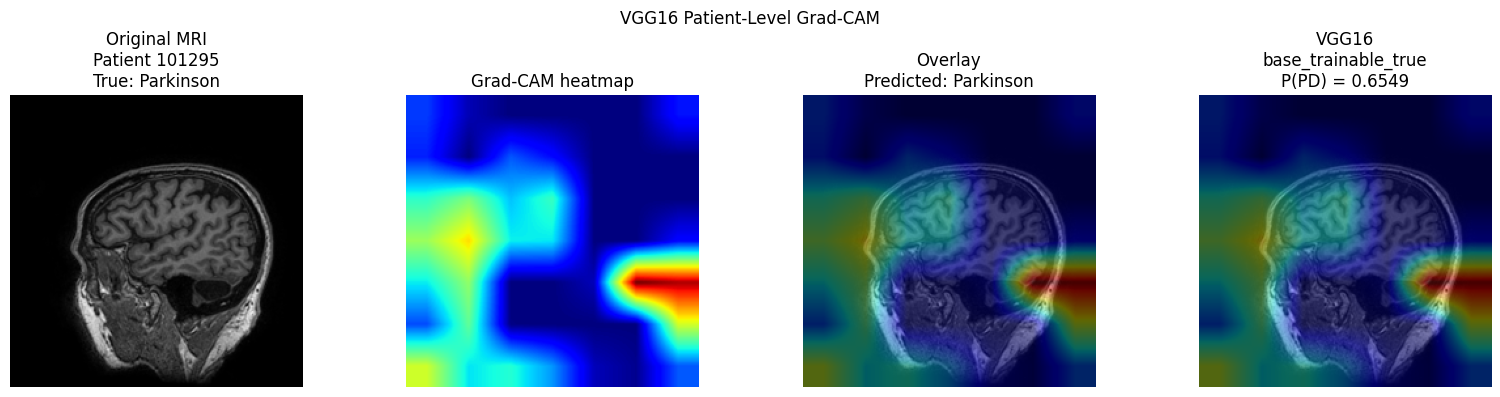

,architecture,model_variant,patient_id,true_label,predicted_label,parkinson_probability,image_path,gradcam_png,gradcam_npz
0,VGG16,base_trainable_false,113447,Healthy,Healthy,0.454375,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
1,VGG16,base_trainable_false,130190,Healthy,Healthy,0.175498,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
2,VGG16,base_trainable_false,101179,Parkinson,Healthy,0.025023,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
3,VGG16,base_trainable_false,101295,Parkinson,Parkinson,0.991300,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
4,VGG16,base_trainable_true,113447,Healthy,Healthy,0.092163,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
5,VGG16,base_trainable_true,130190,Healthy,Healthy,0.009472,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
6,VGG16,base_trainable_true,101179,Parkinson,Healthy,0.029017,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
7,VGG16,base_trainable_true,101295,Parkinson,Parkinson,0.654928,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...


Saved Grad-CAM manifest: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here/gradcam/vgg16_gradcam_manifest.csv
Grad-CAM PNG and NPZ verification passed for 8 files.


In [14]:
# ============================================================
# GRAD-CAM FOR FROZEN AND TRAINABLE VGG16 MODELS
# ============================================================

GRADCAM_PATIENTS_PER_CLASS = 2
GRADCAM_ALPHA = 0.40


def extract_slice_number_for_gradcam(filename):
    match = re.search(
        r"slice_(\d+)",
        str(filename),
        flags=re.IGNORECASE,
    )
    return int(match.group(1)) if match else 0


def select_gradcam_test_samples(
    dataframe,
    patients_per_class=2,
):
    """
    Select one middle MRI slice from several healthy and Parkinson
    patients. Only the patient-level TEST set is used.
    """
    selected_rows = []

    for label in [0, 1]:
        patient_ids = list(
            dataframe.loc[
                dataframe["label"] == label,
                "patient_id",
            ].astype(str).unique()
        )

        patient_ids = sorted(
            patient_ids,
            key=lambda value: int(value),
        )[:patients_per_class]

        for patient_id in patient_ids:
            patient_images = dataframe[
                dataframe["patient_id"].astype(str)
                == str(patient_id)
            ].copy()

            patient_images["slice_number"] = (
                patient_images["filename"].map(
                    extract_slice_number_for_gradcam
                )
            )

            patient_images = patient_images.sort_values(
                ["slice_number", "filename"]
            ).reset_index(drop=True)

            middle_index = len(patient_images) // 2
            selected_rows.append(
                patient_images.iloc[middle_index]
            )

    if not selected_rows:
        raise ValueError(
            "No Grad-CAM test samples were selected."
        )

    return pd.DataFrame(selected_rows).reset_index(
        drop=True
    )


def normalize_gradcam_heatmap(heatmap):
    heatmap = np.maximum(heatmap, 0)
    maximum = np.max(heatmap)

    if maximum <= 0:
        return np.zeros_like(
            heatmap,
            dtype=np.float32,
        )

    return (
        heatmap / maximum
    ).astype(np.float32)


def compute_model_gradcam(
    model,
    preprocessed_batch,
    target_class=None,
):
    """
    Use the tensor entering GlobalAveragePooling2D. This is the final
    convolutional feature map from the pretrained backbone.
    """
    gap_layer = model.get_layer(
        "global_average_pooling"
    )
    convolutional_tensor = gap_layer.input

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            convolutional_tensor,
            model.output,
        ],
    )

    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(
            preprocessed_batch,
            training=False,
        )

        positive_probability = predictions[:, 0]

        if target_class is None:
            target_class = int(
                positive_probability[0] >= 0.50
            )

        if int(target_class) == 1:
            class_score = positive_probability
        else:
            class_score = 1.0 - positive_probability

    gradients = tape.gradient(
        class_score,
        feature_maps,
    )

    if gradients is None:
        raise RuntimeError(
            "Grad-CAM gradients are None."
        )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(1, 2),
    )

    weighted_maps = (
        feature_maps
        * channel_weights[:, None, None, :]
    )

    heatmap = tf.reduce_sum(
        weighted_maps,
        axis=-1,
    )[0].numpy()

    heatmap = normalize_gradcam_heatmap(
        heatmap
    )

    return (
        heatmap,
        float(positive_probability[0]),
        int(target_class),
    )


def resize_and_overlay_gradcam(
    raw_image,
    heatmap,
    alpha=0.40,
):
    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        size=raw_image.shape[:2],
        method="bilinear",
    ).numpy().squeeze()

    resized_heatmap = normalize_gradcam_heatmap(
        resized_heatmap
    )

    colored_heatmap = plt.get_cmap("jet")(
        resized_heatmap
    )[..., :3]

    normalized_image = np.clip(
        raw_image / 255.0,
        0.0,
        1.0,
    )

    overlay = np.clip(
        (1.0 - alpha) * normalized_image
        + alpha * colored_heatmap,
        0.0,
        1.0,
    )

    return (
        resized_heatmap.astype(np.float32),
        colored_heatmap.astype(np.float32),
        overlay.astype(np.float32),
    )


def save_single_gradcam(
    model,
    model_variant,
    sample_row,
):
    image_path = Path(sample_row["filepath"])
    patient_id = str(sample_row["patient_id"])
    true_class = int(sample_row["label"])
    true_label = (
        "Parkinson"
        if true_class == 1
        else "Healthy"
    )

    loaded_image = keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE,
        color_mode="rgb",
    )

    raw_image = keras.utils.img_to_array(
        loaded_image
    ).astype(np.float32)

    # Each notebook already imports the correct architecture-specific
    # preprocess_input function.
    preprocessed_batch = preprocess_input(
        np.expand_dims(
            raw_image.copy(),
            axis=0,
        )
    )

    heatmap, probability, predicted_class = (
        compute_model_gradcam(
            model=model,
            preprocessed_batch=preprocessed_batch,
            target_class=None,
        )
    )

    predicted_label = (
        "Parkinson"
        if predicted_class == 1
        else "Healthy"
    )

    resized_heatmap, colored_heatmap, overlay = (
        resize_and_overlay_gradcam(
            raw_image=raw_image,
            heatmap=heatmap,
            alpha=GRADCAM_ALPHA,
        )
    )

    variant_dir = (
        GRADCAM_DIR / model_variant
    )
    variant_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    safe_stem = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        image_path.stem,
    )

    file_prefix = (
        f"patient_{patient_id}_"
        f"true_{true_label}_"
        f"{safe_stem}"
    )

    png_path = (
        variant_dir
        / f"{file_prefix}_gradcam.png"
    )

    npz_path = (
        variant_dir
        / f"{file_prefix}_gradcam_data.npz"
    )

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(
        np.clip(
            raw_image / 255.0,
            0.0,
            1.0,
        )
    )
    plt.title(
        f"Original MRI\n"
        f"Patient {patient_id}\n"
        f"True: {true_label}"
    )
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(
        resized_heatmap,
        cmap="jet",
    )
    plt.title("Grad-CAM heatmap")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(overlay)
    plt.title(
        f"Overlay\n"
        f"Predicted: {predicted_label}"
    )
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title(
        f"VGG16\n"
        f"{model_variant}\n"
        f"P(PD) = {probability:.4f}"
    )
    plt.axis("off")

    plt.suptitle(
        f"VGG16 Patient-Level Grad-CAM"
    )
    plt.tight_layout()

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    np.savez_compressed(
        npz_path,
        heatmap=heatmap.astype(np.float32),
        resized_heatmap=resized_heatmap.astype(
            np.float32
        ),
        colored_heatmap=colored_heatmap.astype(
            np.float32
        ),
        overlay=overlay.astype(np.float32),
        image_path=np.asarray(
            str(image_path)
        ),
        filename=np.asarray(
            str(image_path.name)
        ),
        patient_id=np.asarray(patient_id),
        true_class=np.asarray(
            true_class,
            dtype=np.int32,
        ),
        true_label=np.asarray(true_label),
        predicted_class=np.asarray(
            predicted_class,
            dtype=np.int32,
        ),
        predicted_label=np.asarray(
            predicted_label
        ),
        parkinson_probability=np.asarray(
            probability,
            dtype=np.float32,
        ),
        model_variant=np.asarray(
            model_variant
        ),
        architecture=np.asarray(
            "VGG16"
        ),
        evaluation_split=np.asarray(
            "patient_level_test"
        ),
    )

    return {
        "architecture": "VGG16",
        "model_variant": model_variant,
        "patient_id": patient_id,
        "true_label": true_label,
        "predicted_label": predicted_label,
        "parkinson_probability": probability,
        "image_path": str(image_path),
        "gradcam_png": str(png_path),
        "gradcam_npz": str(npz_path),
    }


gradcam_samples = select_gradcam_test_samples(
    test_df,
    patients_per_class=GRADCAM_PATIENTS_PER_CLASS,
)

print("GRAD-CAM TEST SAMPLES")
display(
    gradcam_samples[
        [
            "patient_id",
            "label",
            "class_name",
            "filename",
        ]
    ]
)


gradcam_model_specs = [
    (
        "base_trainable_false",
        Path(frozen_run_dir / f"{FROZEN_RUN_NAME}_best_model.keras"),
    ),
    (
        "base_trainable_true",
        Path(trainable_run_dir / f"{TRAINABLE_RUN_NAME}_best_model.keras"),
    ),
]


gradcam_manifest_rows = []

for model_variant, saved_model_path in gradcam_model_specs:
    if not saved_model_path.exists():
        raise FileNotFoundError(
            f"Saved model not found: {saved_model_path}"
        )

    print(
        "\nLoading Grad-CAM model:",
        saved_model_path,
    )

    gradcam_model = keras.models.load_model(
        saved_model_path,
        compile=False,
    )

    for _, sample_row in gradcam_samples.iterrows():
        gradcam_manifest_rows.append(
            save_single_gradcam(
                model=gradcam_model,
                model_variant=model_variant,
                sample_row=sample_row,
            )
        )

    del gradcam_model
    tf.keras.backend.clear_session()
    gc.collect()


gradcam_manifest_df = pd.DataFrame(
    gradcam_manifest_rows
)

gradcam_manifest_path = (
    GRADCAM_DIR
    / "vgg16_gradcam_manifest.csv"
)

gradcam_manifest_df.to_csv(
    gradcam_manifest_path,
    index=False,
)

display(gradcam_manifest_df)

print(
    "Saved Grad-CAM manifest:",
    gradcam_manifest_path,
)


# Verify every raw Grad-CAM NPZ file.
gradcam_npz_files = sorted(
    GRADCAM_DIR.rglob(
        "*_gradcam_data.npz"
    )
)

assert len(gradcam_npz_files) > 0

gradcam_verification_rows = []

for gradcam_npz_file in gradcam_npz_files:
    with np.load(
        gradcam_npz_file,
        allow_pickle=False,
    ) as gradcam_data:
        required_keys = {
            "heatmap",
            "resized_heatmap",
            "overlay",
            "patient_id",
            "true_label",
            "predicted_label",
            "parkinson_probability",
            "model_variant",
            "architecture",
        }

        missing_keys = (
            required_keys
            - set(gradcam_data.files)
        )

        if missing_keys:
            raise KeyError(
                f"{gradcam_npz_file} is missing "
                f"keys: {sorted(missing_keys)}"
            )

        gradcam_verification_rows.append(
            {
                "file": str(gradcam_npz_file),
                "keys": ", ".join(
                    gradcam_data.files
                ),
                "heatmap_shape": str(
                    gradcam_data[
                        "heatmap"
                    ].shape
                ),
                "loads_successfully": True,
            }
        )

gradcam_verification_df = pd.DataFrame(
    gradcam_verification_rows
)

gradcam_verification_df.to_csv(
    GRADCAM_DIR
    / "vgg16_gradcam_npz_verification.csv",
    index=False,
)

print(
    "Grad-CAM PNG and NPZ verification passed for",
    len(gradcam_npz_files),
    "files.",
)

## 8. Compare both patient-level ROC curves and create a combined NPZ

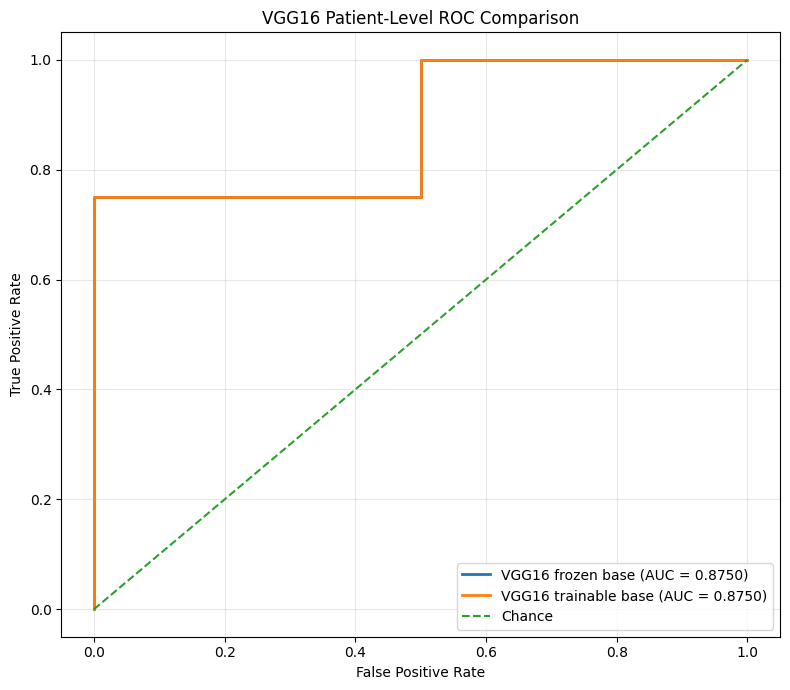

,model,split_level,aggregation,decision_threshold,number_of_test_patients,number_of_test_images,patient_accuracy,patient_precision,patient_recall,patient_f1,patient_specificity,patient_negative_predictive_value,patient_balanced_accuracy,patient_matthews_correlation_coefficient,true_negative,false_positive,false_negative,true_positive,patient_roc_auc
0,vgg16_base_frozen_patient_level,patient,mean,0.5,8,1916,0.875,1.0,0.75,0.857143,1.0,0.8,0.875,0.774597,4,0,1,3,0.875
1,vgg16_base_trainable_patient_level,patient,mean,0.5,8,1916,0.875,1.0,0.75,0.857143,1.0,0.8,0.875,0.774597,4,0,1,3,0.875


Saved combined ROC NPZ: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here/vgg16_patient_level_roc_comparison.npz
Saved comparison ROC plot: /content/drive/MyDrive/Patient_level_classification/VGG16_single_model_patient_level_data_save_here/vgg16_patient_level_roc_comparison.png


In [15]:

frozen_npz_path = (
    Path(OUTPUT_DIR) / "vgg16_base_frozen_patient_level_roc.npz"
)
trainable_npz_path = (
    Path(OUTPUT_DIR) / "vgg16_base_trainable_patient_level_roc.npz"
)

with np.load(frozen_npz_path, allow_pickle=False) as frozen_roc:
    frozen_fpr = frozen_roc["fpr"]
    frozen_tpr = frozen_roc["tpr"]
    frozen_thresholds = frozen_roc["thresholds"]
    frozen_auc = float(frozen_roc["auc"])
    frozen_y_true = frozen_roc["y_true"]
    frozen_y_score = frozen_roc["y_score"]
    frozen_patient_ids = frozen_roc["patient_ids"]

with np.load(trainable_npz_path, allow_pickle=False) as trainable_roc:
    trainable_fpr = trainable_roc["fpr"]
    trainable_tpr = trainable_roc["tpr"]
    trainable_thresholds = trainable_roc["thresholds"]
    trainable_auc = float(trainable_roc["auc"])
    trainable_y_true = trainable_roc["y_true"]
    trainable_y_score = trainable_roc["y_score"]
    trainable_patient_ids = trainable_roc["patient_ids"]

# Both models must use the same patient-level test set.
assert np.array_equal(frozen_patient_ids, trainable_patient_ids)
assert np.array_equal(frozen_y_true, trainable_y_true)

plt.figure(figsize=(8, 7))
plt.plot(
    frozen_fpr,
    frozen_tpr,
    linewidth=2,
    label=f"VGG16 frozen base (AUC = {frozen_auc:.4f})",
)
plt.plot(
    trainable_fpr,
    trainable_tpr,
    linewidth=2,
    label=f"VGG16 trainable base (AUC = {trainable_auc:.4f})",
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG16 Patient-Level ROC Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

comparison_roc_png = (
    Path(OUTPUT_DIR) / "vgg16_patient_level_roc_comparison.png"
)
plt.savefig(comparison_roc_png, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

comparison_npz_path = (
    Path(OUTPUT_DIR) / "vgg16_patient_level_roc_comparison.npz"
)

np.savez_compressed(
    comparison_npz_path,
    patient_ids=frozen_patient_ids,
    y_true=frozen_y_true,
    frozen_y_score=frozen_y_score,
    frozen_fpr=frozen_fpr,
    frozen_tpr=frozen_tpr,
    frozen_thresholds=frozen_thresholds,
    frozen_auc=np.asarray(frozen_auc, dtype=np.float64),
    trainable_y_score=trainable_y_score,
    trainable_fpr=trainable_fpr,
    trainable_tpr=trainable_tpr,
    trainable_thresholds=trainable_thresholds,
    trainable_auc=np.asarray(trainable_auc, dtype=np.float64),
    aggregation=np.asarray(PATIENT_AGGREGATION),
    split_level=np.asarray("patient"),
    positive_class=np.asarray("parkinson_dataset"),
    negative_class=np.asarray("healthy_dataset"),
)

comparison_metrics = pd.DataFrame(
    [
        frozen_results["metrics"],
        trainable_results["metrics"],
    ]
)
comparison_metrics.to_csv(
    Path(OUTPUT_DIR) / "vgg16_patient_level_metrics_comparison.csv",
    index=False,
)

display(comparison_metrics)
print("Saved combined ROC NPZ:", comparison_npz_path)
print("Saved comparison ROC plot:", comparison_roc_png)


## 9. Verify the contents of the ROC NPZ files

In [16]:

roc_files = [
    Path(OUTPUT_DIR) / "vgg16_base_frozen_patient_level_roc.npz",
    Path(OUTPUT_DIR) / "vgg16_base_trainable_patient_level_roc.npz",
    Path(OUTPUT_DIR) / "vgg16_patient_level_roc_comparison.npz",
]

for roc_file in roc_files:
    print("\nFILE:", roc_file.name)
    with np.load(roc_file, allow_pickle=False) as roc_data:
        print("Keys:", roc_data.files)
        for key in roc_data.files:
            value = roc_data[key]
            print(f"  {key}: shape={value.shape}, dtype={value.dtype}")



FILE: vgg16_base_frozen_patient_level_roc.npz
Keys: ['patient_ids', 'y_true', 'y_score', 'y_pred', 'fpr', 'tpr', 'thresholds', 'auc', 'decision_threshold', 'aggregation', 'split_level', 'positive_class', 'negative_class', 'number_of_images', 'model_name']
  patient_ids: shape=(8,), dtype=<U6
  y_true: shape=(8,), dtype=int64
  y_score: shape=(8,), dtype=float64
  y_pred: shape=(8,), dtype=int64
  fpr: shape=(6,), dtype=float64
  tpr: shape=(6,), dtype=float64
  thresholds: shape=(6,), dtype=float64
  auc: shape=(), dtype=float64
  decision_threshold: shape=(), dtype=float64
  aggregation: shape=(), dtype=<U4
  split_level: shape=(), dtype=<U7
  positive_class: shape=(), dtype=<U17
  negative_class: shape=(), dtype=<U15
  number_of_images: shape=(8,), dtype=int64
  model_name: shape=(), dtype=<U31

FILE: vgg16_base_trainable_patient_level_roc.npz
Keys: ['patient_ids', 'y_true', 'y_score', 'y_pred', 'fpr', 'tpr', 'thresholds', 'auc', 'decision_threshold', 'aggregation', 'split_level', '

## 10. Example: reload an NPZ later and plot the ROC curve

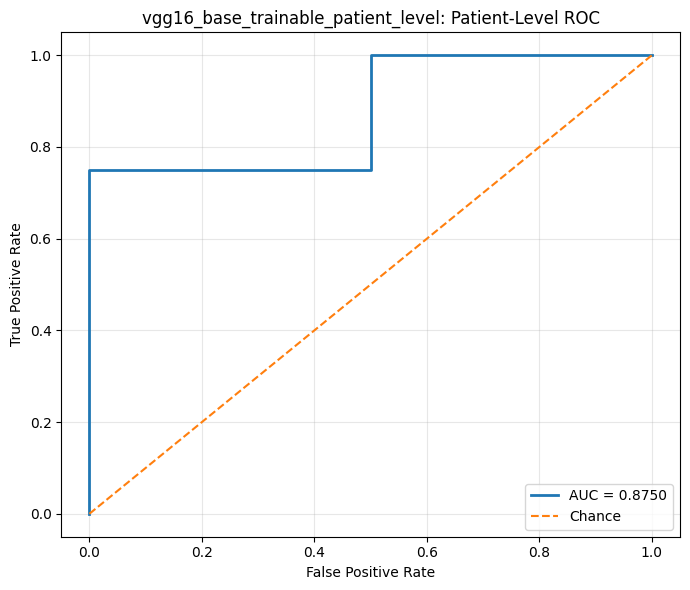

In [17]:

# Change this path to either individual model's ROC NPZ file.

ROC_FILE_TO_LOAD = (
    Path(OUTPUT_DIR) / "vgg16_base_trainable_patient_level_roc.npz"
)

with np.load(ROC_FILE_TO_LOAD, allow_pickle=False) as roc_data:
    fpr = roc_data["fpr"]
    tpr = roc_data["tpr"]
    auc_value = float(roc_data["auc"])
    model_name = str(roc_data["model_name"])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model_name}: Patient-Level ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Create a small ZIP containing the ROC artifacts

In [18]:

# This ZIP excludes the large model files and contains the ROC-related
# results, metrics, reports, predictions, and split information.

roc_package_dir = Path("/content/vgg16_patient_level_roc_package")
if roc_package_dir.exists():
    shutil.rmtree(roc_package_dir)
roc_package_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    Path(OUTPUT_DIR) / "vgg16_base_frozen_patient_level_roc.npz",
    Path(OUTPUT_DIR) / "vgg16_base_trainable_patient_level_roc.npz",
    Path(OUTPUT_DIR) / "vgg16_patient_level_roc_comparison.npz",
    Path(OUTPUT_DIR) / "vgg16_patient_level_roc_comparison.png",
    Path(OUTPUT_DIR) / "vgg16_patient_level_metrics_comparison.csv",
]

for file_path in files_to_copy:
    if file_path.exists():
        shutil.copy2(file_path, roc_package_dir / file_path.name)

# Copy the split CSV files.
split_source = Path(OUTPUT_DIR) / "patient_splits"
if split_source.exists():
    shutil.copytree(
        split_source,
        roc_package_dir / "patient_splits",
        dirs_exist_ok=True,
    )

# Copy Grad-CAM PNG images, raw NPZ heatmaps and verification files.
gradcam_source = Path(GRADCAM_DIR)
if gradcam_source.exists():
    shutil.copytree(
        gradcam_source,
        roc_package_dir / "gradcam",
        dirs_exist_ok=True,
    )

# Copy model-specific small reports and plots, excluding model/weight files.
for run_name in [FROZEN_RUN_NAME, TRAINABLE_RUN_NAME]:
    source_dir = Path(OUTPUT_DIR) / run_name
    destination_dir = roc_package_dir / run_name
    destination_dir.mkdir(parents=True, exist_ok=True)

    for file_path in source_dir.iterdir():
        if file_path.suffix.lower() not in {".keras", ".h5"}:
            shutil.copy2(file_path, destination_dir / file_path.name)

zip_base = "/content/vgg16_patient_level_roc_files"
zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir=roc_package_dir,
)

print("Created:", zip_path)


Created: /content/vgg16_patient_level_roc_files.zip


In [19]:

# Download the ROC package to the computer.

from google.colab import files
files.download("/content/vgg16_patient_level_roc_files.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Important interpretation

- Patient IDs are extracted from `PPMI_<PatientID>_...`.
- `control_png` and `pd_png` are ignored as patient IDs.
- The notebook stops before training unless it detects exactly 52 patients.
- The exact class composition is 23 healthy and 29 Parkinson patients.
- With seed 42, the split is:
  - Training: 16 healthy + 20 Parkinson = 36
  - Validation: 3 healthy + 5 Parkinson = 8
  - Testing: 4 healthy + 4 Parkinson = 8
- Each patient belongs to one split only.
- VGG16 trains on individual MRI slices.
- Final probabilities and metrics are aggregated at patient level.
- Grad-CAM is generated only from patient-level test images for both frozen and trainable VGG16 models.